In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")

In [25]:
df = pd.read_excel(r"C:\Users\zeine\OneDrive\Documents\bachelor thesis\data\audio_lanzhou_2015\audio_lanzhou_2015\subjects_information_audio_lanzhou_2015.xlsx")

df.head()

,subject id,type,age,gender,education（years）,PHQ-9,CTQ-SF,LES,SSRS,GAD-7,PSQI,Unnamed: 11,Unnamed: 12
0,2010002,MDD,18,F,12,23,77,-143,31,18,12,NaN,abbreviation
1,2010004,MDD,25,F,19,12,53,-44,38,13,11,NaN,MDD = Major Depressive Disorder
2,2010005,MDD,20,M,16,19,49,-3,28,11,5,NaN,HC = Healthy Control
3,2010006,MDD,42,M,16,16,59,-30,40,12,9,NaN,PHQ-9 = Patient Health Questionnaire
4,2010008,MDD,42,M,12,17,66,-71,44,18,13,NaN,CTQ-SF = Childhood Trauma Questionnaire


In [26]:
print("Shape of the dataset:", df.shape)
df.info()

Shape of the dataset: (52, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   subject id        52 non-null     int64  
 1   type              52 non-null     object 
 2   age               52 non-null     int64  
 3   gender            52 non-null     object 
 4   education（years）  52 non-null     int64  
 5   PHQ-9             52 non-null     int64  
 6   CTQ-SF            52 non-null     int64  
 7   LES               52 non-null     int64  
 8   SSRS              52 non-null     int64  
 9   GAD-7             52 non-null     int64  
 10  PSQI              52 non-null     int64  
 11  Unnamed: 11       0 non-null      float64
 12  Unnamed: 12       11 non-null     object 
dtypes: float64(1), int64(9), object(3)
memory usage: 5.4+ KB


In [27]:
df.describe()

,subject id,age,education（years）,PHQ-9,CTQ-SF,LES,SSRS,GAD-7,PSQI,Unnamed: 11
count,5.200000e+01,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,0.0
mean,2.018091e+06,31.269231,15.038462,9.403846,46.076923,-15.134615,37.807692,7.288462,7.403846,NaN
std,8.171502e+03,9.205956,3.693988,8.481259,10.724438,50.176172,8.291357,7.132737,5.528038,NaN
min,2.010001e+06,18.000000,6.000000,0.000000,33.000000,-194.000000,18.000000,0.000000,0.000000,NaN
25%,2.010015e+06,23.000000,12.000000,2.750000,38.750000,-17.750000,33.500000,1.000000,3.000000,NaN
50%,2.020009e+06,29.500000,16.000000,4.500000,43.000000,-2.000000,40.000000,4.000000,6.000000,NaN
75%,2.022520e+06,38.500000,16.000000,18.000000,50.250000,0.000000,42.000000,13.000000,11.000000,NaN
max,2.030017e+06,52.000000,23.000000,25.000000,83.000000,147.000000,53.000000,21.000000,21.000000,NaN


In [28]:
df.columns.tolist()

['subject id',
 'type',
 'age',
 'gender',
 'education（years）',
 'PHQ-9',
 'CTQ-SF',
 'LES',
 'SSRS',
 'GAD-7',
 'PSQI',
 'Unnamed: 11',
 'Unnamed: 12']

In [29]:
# Missing values

missing = df.isnull().sum()
print(missing[missing > 0])

Unnamed: 11    52
Unnamed: 12    41
dtype: int64


In [30]:
# Cleaning columns: drop spreadsheet artifacts, fix full-width parens, standardize names
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")])
df = df.rename(columns={
    "subject id": "subject_id",
    "education（years）": "education_years",
    "PHQ-9": "PHQ9", "CTQ-SF": "CTQSF", "GAD-7": "GAD7"
})

clinical_vars = ["age", "education_years", "PHQ9", "CTQSF", "LES", "SSRS", "GAD7", "PSQI"]

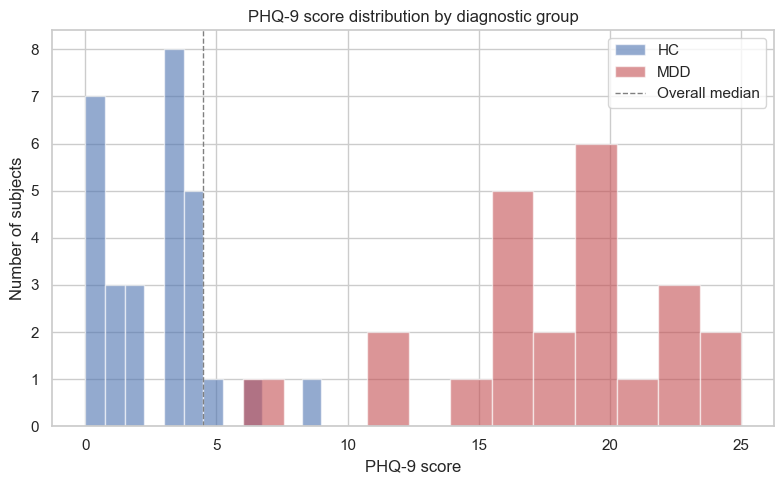

In [31]:
# --- Figure 1: PHQ-9 distribution by diagnostic group ---
plt.figure(figsize=(8, 5))
for grp, color in [("HC", "#4C72B0"), ("MDD", "#C44E52")]:
    subset = df.loc[df["type"] == grp, "PHQ9"]
    plt.hist(subset, bins=12, alpha=0.6, label=grp, color=color, edgecolor="white")
plt.axvline(df["PHQ9"].median(), color="grey", linestyle="--", linewidth=1, label="Overall median")
plt.xlabel("PHQ-9 score")
plt.ylabel("Number of subjects")
plt.title("PHQ-9 score distribution by diagnostic group")
plt.legend()
plt.tight_layout()
plt.savefig("phq9_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

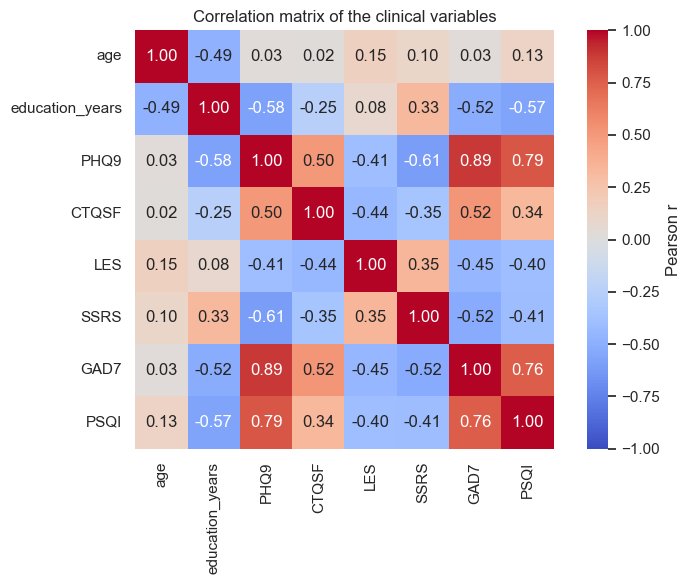

In [32]:
# --- Figure 2: Correlation matrix of clinical/demographic variables ---
corr = df[clinical_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Pearson r"})
plt.title("Correlation matrix of the clinical variables")
plt.tight_layout()
plt.savefig("clinical_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


In [33]:
# Correlation with target variable PHQ 9

corr_with_target = df[clinical_vars].corr()["PHQ9"].sort_values(ascending=False)
print(corr_with_target)

PHQ9               1.000000
GAD7               0.890354
PSQI               0.786041
CTQSF              0.504524
age                0.025200
LES               -0.405658
education_years   -0.579422
SSRS              -0.608124
Name: PHQ9, dtype: float64


In [34]:
# Sample characteristics table (Data section)
import pandas as pd, numpy as np
from pathlib import Path

DATA_DIR = Path.cwd()
if not (DATA_DIR / "subjects_information_audio_lanzhou_2015.xlsx").exists():
    DATA_DIR = DATA_DIR.parent

xl = pd.read_excel(DATA_DIR / "subjects_information_audio_lanzhou_2015.xlsx")
xl["k"] = xl["subject id"].astype("Int64")

# Restrict to the 52 subjects actually analysed (those in model_df)
md = pd.read_csv(DATA_DIR / "model_df.csv", dtype={"subject_key": str})
df = xl[xl["k"].isin(set(md["subject_key"].astype(int)))].copy()

EDU = "education（years）"   # note the full-width parentheses in the column name
groups = {"MDD": df[df["type"] == "MDD"], "HC": df[df["type"] == "HC"], "Total": df}
cont = [("Age", "age"), ("Education years", EDU), ("PHQ-9", "PHQ-9"),
        ("CTQ-SF", "CTQ-SF"), ("LES", "LES"), ("SSRS", "SSRS"),
        ("GAD-7", "GAD-7"), ("PSQI", "PSQI")]

def ms(s):  return f"{s.mean():.1f} ({s.std():.1f})"
def fm(d):  v = d["gender"].value_counts(); return f"{v.get('F', 0)}/{v.get('M', 0)}"

n = {g: len(d) for g, d in groups.items()}
rows = [
    ("Age, mean (SD)",  [ms(groups[g]["age"]) for g in groups]),
]
# build the LaTeX body
lines = []
lines.append(f"Age, mean (SD)             & {ms(groups['MDD']['age'])} & {ms(groups['HC']['age'])} & {ms(groups['Total']['age'])} \\\\")
lines.append(f"Gender, F/M                & {fm(groups['MDD'])} & {fm(groups['HC'])} & {fm(groups['Total'])} \\\\")
lines.append(f"Education years, mean (SD) & {ms(groups['MDD'][EDU])} & {ms(groups['HC'][EDU])} & {ms(groups['Total'][EDU])} \\\\")
for label, col in cont[2:]:   # PHQ-9 onward
    lines.append(f"{label+', mean (SD)':<26} & {ms(groups['MDD'][col])} & {ms(groups['HC'][col])} & {ms(groups['Total'][col])} \\\\")

latex = r"""\begin{table}[htbp]
\centering
\caption{Clinical characteristics of the sample.}
\label{tab:sample-characteristics}
\begin{tabular}{lccc}
\toprule
Variable & MDD (n=%d) & HC (n=%d) & Total (N=%d) \\
\midrule
%s
\bottomrule
\end{tabular}
\end{table}""" % (n["MDD"], n["HC"], n["Total"], "\n".join(lines))

print(latex)


\begin{table}[htbp]
\centering
\caption{Clinical characteristics of the sample.}
\label{tab:sample-characteristics}
\begin{tabular}{lccc}
\toprule
Variable & MDD (n=23) & HC (n=29) & Total (N=52) \\
\midrule
Age, mean (SD)             & 30.9 (9.7) & 31.6 (8.9) & 31.3 (9.2) \\
Gender, F/M                & 7/16 & 9/20 & 16/36 \\
Education years, mean (SD) & 12.9 (3.7) & 16.8 (2.6) & 15.0 (3.7) \\
PHQ-9, mean (SD)           & 18.1 (4.4) & 2.5 (2.1) & 9.4 (8.5) \\
CTQ-SF, mean (SD)          & 51.8 (11.6) & 41.5 (7.5) & 46.1 (10.7) \\
LES, mean (SD)             & -40.7 (58.6) & 5.1 (30.4) & -15.1 (50.2) \\
SSRS, mean (SD)            & 32.4 (7.7) & 42.1 (6.0) & 37.8 (8.3) \\
GAD-7, mean (SD)           & 14.3 (4.6) & 1.7 (2.0) & 7.3 (7.1) \\
PSQI, mean (SD)            & 12.1 (4.7) & 3.7 (2.3) & 7.4 (5.5) \\
\bottomrule
\end{tabular}
\end{table}


C:\Users\zeine\AppData\Local\Temp\ipykernel_23332\4251642941.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="type", y=var, ax=ax, palette=["#4C72B0", "#C44E52"])


ValueError: Could not interpret value `education_years` for `y`. An entry with this name does not appear in `data`.

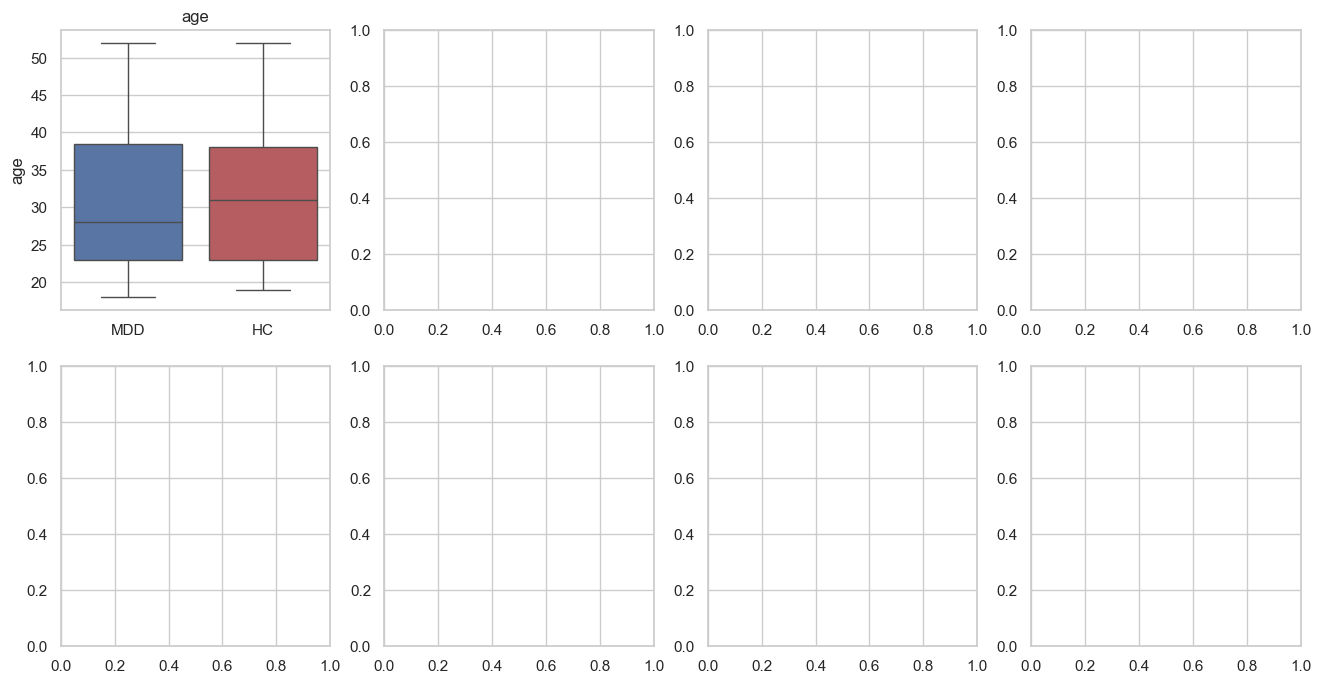

In [35]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, var in zip(axes.flat, clinical_vars):
    sns.boxplot(data=df, x="type", y=var, ax=ax, palette=["#4C72B0", "#C44E52"])
    ax.set_title(var)
    ax.set_xlabel("")
plt.suptitle("Clinical (demographics + psych) variables by diagnostic group")
plt.tight_layout()
plt.savefig("clinical_boxplots_by_group.png", dpi=300, bbox_inches="tight")
plt.show()